# Examine GP Activation NPZ

Inspect aggregated activation logs (e.g., `GP/datasets/raw/<run_id>/activations_all.npz`).

This notebook prints summary statistics and plots seaborn histograms per signal. If epoch metadata is present (`<signal>_epoch`), counts per epoch are shown.

In [7]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Point to your aggregated NPZ
# Example: Path("./GP/datasets/raw/<run_id>/activations_all.npz")
npz_path = Path("/home/ethan/experiments/llm_gp/llm/GP/datasets/raw/20251116_210338/activations_all.npz")
assert npz_path.exists(), f"NPZ not found: {npz_path}"
data = np.load(npz_path)
signals = [k for k in data.files if not k.endswith("_epoch")]
print(f"Loaded signals: {signals}")

Loaded signals: ['layer0_rms_mean_sq', 'layer0_gate_u', 'layer0_gate_v', 'layer0_silu_in', 'layer1_rms_mean_sq', 'layer1_gate_u', 'layer1_gate_v', 'layer1_silu_in']



layer0_rms_mean_sq summary:
  count: 1126400
  min: 0.5804398655891418
  max: 3.2612578868865967
  mean: 1.0275659561157227
  std: 0.16385355591773987
  p1: 0.74675452709198
  p50: 1.0082268714904785
  p99: 1.5797127485275269
Per-epoch counts for layer0_rms_mean_sq:
  epoch -1: 1126400


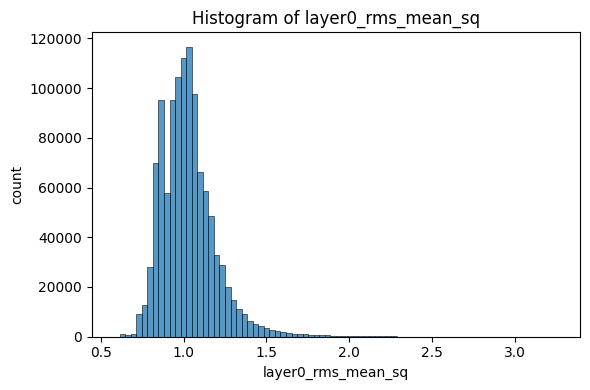


layer0_gate_u summary:
  count: 5500000
  min: -3.692377805709839
  max: 4.06924295425415
  mean: 0.06537553668022156
  std: 0.7696405649185181
  p1: -1.6658812761306763
  p50: 0.04553135856986046
  p99: 1.9624308347702026
Per-epoch counts for layer0_gate_u:
  epoch -1: 5500000


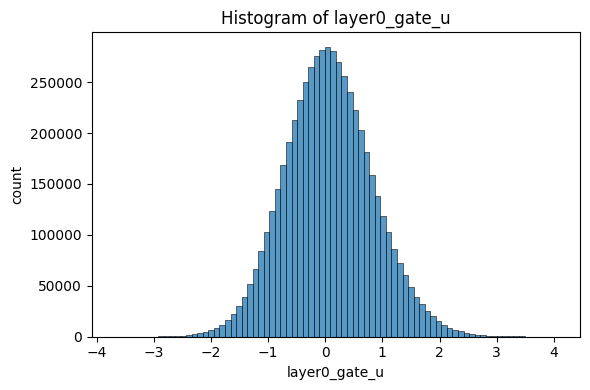


layer0_gate_v summary:
  count: 5500000
  min: -3.5627963542938232
  max: 3.8197665214538574
  mean: 0.007643214426934719
  std: 0.7708382606506348
  p1: -1.8071106672286987
  p50: 0.0041381437331438065
  p99: 1.835677146911621
Per-epoch counts for layer0_gate_v:
  epoch -1: 5500000


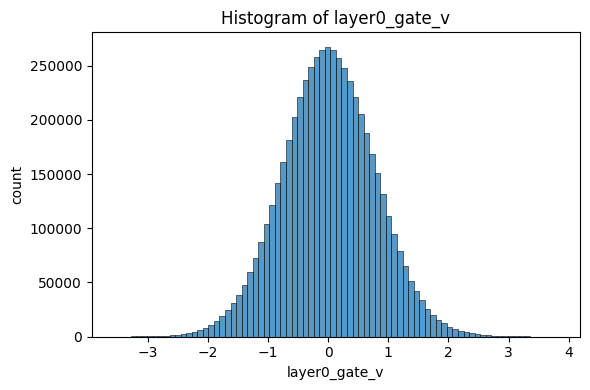


layer0_silu_in summary:
  count: 5500000
  min: -3.7371222972869873
  max: 4.085958480834961
  mean: 0.06639470160007477
  std: 0.7704285383224487
  p1: -1.6662918329238892
  p50: 0.046939507126808167
  p99: 1.9669873714447021
Per-epoch counts for layer0_silu_in:
  epoch -1: 5500000


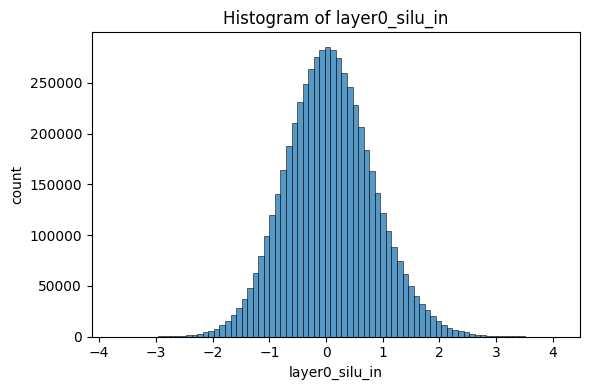


layer1_rms_mean_sq summary:
  count: 1126400
  min: 0.68352210521698
  max: 24.04222869873047
  mean: 2.9838790893554688
  std: 1.851029872894287
  p1: 1.0495351552963257
  p50: 2.305196762084961
  p99: 9.098361015319824
Per-epoch counts for layer1_rms_mean_sq:
  epoch -1: 1126400


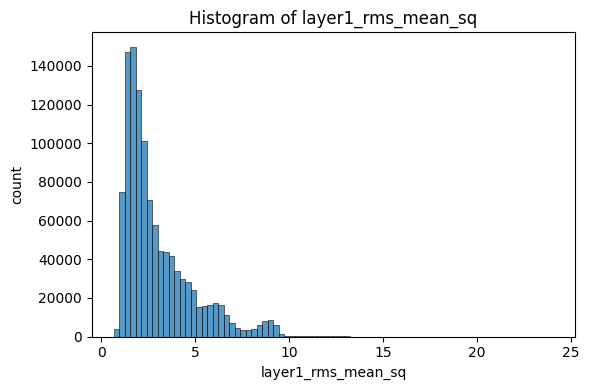


layer1_gate_u summary:
  count: 5500000
  min: -3.8671774864196777
  max: 4.464664936065674
  mean: 0.34102922677993774
  std: 0.8384671807289124
  p1: -1.5915992259979248
  p50: 0.33090338110923767
  p99: 2.3225624561309814
Per-epoch counts for layer1_gate_u:
  epoch -1: 5500000


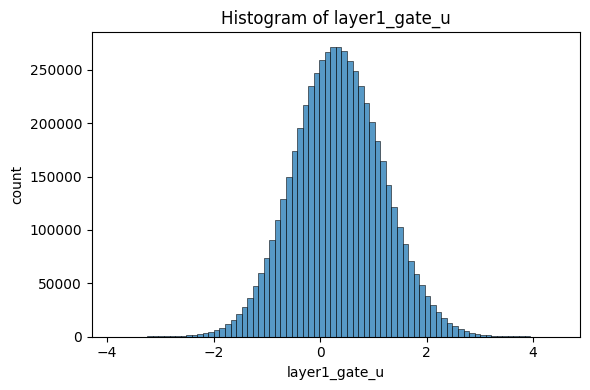


layer1_gate_v summary:
  count: 5500000
  min: -3.8326528072357178
  max: 4.698126316070557
  mean: -0.018915383145213127
  std: 0.897746205329895
  p1: -2.0833170413970947
  p50: -0.022072479128837585
  p99: 2.0445351600646973
Per-epoch counts for layer1_gate_v:
  epoch -1: 5500000


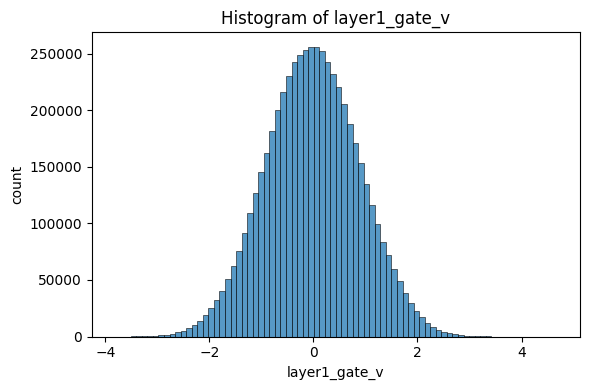


layer1_silu_in summary:
  count: 5500000
  min: -4.028429985046387
  max: 4.530822277069092
  mean: 0.3412073254585266
  std: 0.8384285569190979
  p1: -1.5933133363723755
  p50: 0.3311113715171814
  p99: 2.322997570037842
Per-epoch counts for layer1_silu_in:
  epoch -1: 5500000


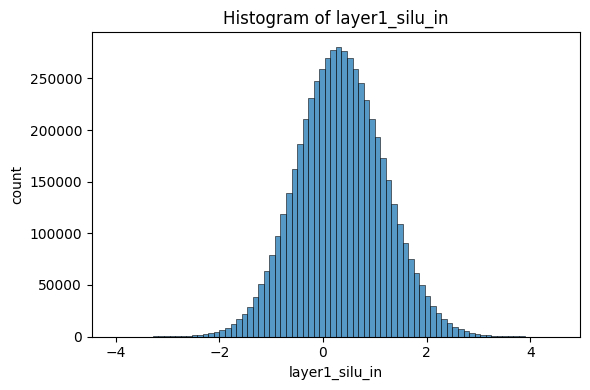

In [8]:
def summarize_array(arr: np.ndarray, name: str):
    arr = arr.astype(np.float32)
    stats = {
        "count": arr.size,
        "min": float(np.min(arr)) if arr.size else None,
        "max": float(np.max(arr)) if arr.size else None,
        "mean": float(np.mean(arr)) if arr.size else None,
        "std": float(np.std(arr)) if arr.size else None,
        "p1": float(np.percentile(arr, 1)) if arr.size else None,
        "p50": float(np.percentile(arr, 50)) if arr.size else None,
        "p99": float(np.percentile(arr, 99)) if arr.size else None,
    }
    print(f"\n{name} summary:")
    for k, v in stats.items():
        print(f"  {k}: {v}")

def per_epoch_counts(sig: str):
    ep_key = f"{sig}_epoch"
    if ep_key not in data:
        print(f"No epoch info for {sig}")
        return
    epochs = data[ep_key]
    counts = defaultdict(int)
    for ep in epochs:
        counts[int(ep)] += 1
    print(f"Per-epoch counts for {sig}:")
    for ep, cnt in sorted(counts.items()):
        print(f"  epoch {ep}: {cnt}")

for sig in signals:
    arr = data[sig]
    summarize_array(arr, sig)
    per_epoch_counts(sig)
    if arr.size:
        plt.figure(figsize=(6, 4))
        sns.histplot(arr, bins=80, kde=False)
        plt.title(f"Histogram of {sig}")
        plt.xlabel(sig)
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

# A good formula

In [1]:
import torch

def expr_torch(x):
    # Accept Python floats / lists as well
    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)

    return (-0.1248 * (
        (((-1.047 * x) +
          ((2.346 * (x + 3.576)) * ((2.346 * -0.9396) * (3.809 + 1.33)))) +
         (
             (
                 (-0.1248 * (
                     (
                         (
                             (x + (2.437 * x)) *
                             ((2.346 * -0.9396) * 3.221)
                         ) +
                         (
                             (2.346 * -0.9396) *
                             (
                                 ((3.809 + x) *
                                  (
                                      ((2.346 * ((-2.417 + x) * x)) *
                                       (2.346 * -0.9396)) +
                                      (2.437 * x)
                                  )
                                 ) +
                                 (3.809 + x)
                             )
                         ) +
                         -2.236
                     ) +
                     (
                         (
                             1.494 +
                             (
                                 ((3.809 + x) *
                                  (
                                      (2.346 *
                                       ((-2.417 + x) *
                                        (3.809 + (1.906 + 2.385)))) *
                                      (2.346 * -0.9396)
                                  ) +
                                  0.6062
                                 )
                             ) +
                             (
                                 (
                                     ((-2.417 + x) * x) +
                                     (2.346 * (3.809 + 1.33))
                                 ) +
                                 (x * x) +
                                 x
                             )
                         ) *
                         (3.809 +
                          ((x + (0.08281 + x)) + (3.809 + 1.33)))
                     )
                 )) *
                 (
                     ((x + x) * (2.346 * -0.9396)) +
                     ((x + x) + (2.437 * x))
                 )
             ) +
             (
                 (3.809 + x) *
                 (
                     ((x + (0.1279 + x)) * (2.346 * -0.9396)) +
                     (3.918 * -0.9396)
                 )
             ) +
             (
                 (-0.5138 * (x + ((0.3614 + x) + 0.5313))) +
                 ((2.346 * -0.9396) * (3.809 + 1.33))
             ) +
             (
                 -1.891 * (-2.07 + (3.809 + 3.848))
             )
         )
        ) *
        (
            ((x + x) * (2.346 * -0.9396)) +
            ((x + x) + (2.437 * x))
        )
    ))


In [2]:
import numpy as np

def expr_numpy(x):
    x = np.asarray(x, dtype=np.float64)

    return (-0.1248 * (
        (((-1.047 * x) +
          ((2.346 * (x + 3.576)) * ((2.346 * -0.9396) * (3.809 + 1.33)))) +
         (
             (
                 (-0.1248 * (
                     (
                         (
                             (x + (2.437 * x)) *
                             ((2.346 * -0.9396) * 3.221)
                         ) +
                         (
                             (2.346 * -0.9396) *
                             (
                                 ((3.809 + x) *
                                  (
                                      ((2.346 * ((-2.417 + x) * x)) *
                                       (2.346 * -0.9396)) +
                                      (2.437 * x)
                                  )
                                 ) +
                                 (3.809 + x)
                             )
                         ) +
                         -2.236
                     ) +
                     (
                         (
                             1.494 +
                             (
                                 ((3.809 + x) *
                                  (
                                      (2.346 *
                                       ((-2.417 + x) *
                                        (3.809 + (1.906 + 2.385)))) *
                                      (2.346 * -0.9396)
                                  ) +
                                  0.6062
                                 )
                             ) +
                             (
                                 (
                                     ((-2.417 + x) * x) +
                                     (2.346 * (3.809 + 1.33))
                                 ) +
                                 (x * x) +
                                 x
                             )
                         ) *
                         (3.809 +
                          ((x + (0.08281 + x)) + (3.809 + 1.33)))
                     )
                 )) *
                 (
                     ((x + x) * (2.346 * -0.9396)) +
                     ((x + x) + (2.437 * x))
                 )
             ) +
             (
                 (3.809 + x) *
                 (
                     ((x + (0.1279 + x)) * (2.346 * -0.9396)) +
                     (3.918 * -0.9396)
                 )
             ) +
             (
                 (-0.5138 * (x + ((0.3614 + x) + 0.5313))) +
                 ((2.346 * -0.9396) * (3.809 + 1.33))
             ) +
             (
                 -1.891 * (-2.07 + (3.809 + 3.848))
             )
         )
        ) *
        (
            ((x + x) * (2.346 * -0.9396)) +
            ((x + x) + (2.437 * x))
        )
    ))


In [3]:
# NumPy
xs = np.linspace(-5, 5, 1000)
ys = expr_numpy(xs)

# PyTorch
xt = torch.linspace(-5, 5, 1000)
yt = expr_torch(xt)


In [4]:
xs.shape

(1000,)

In [7]:
import math
import torch
from torch import nn, Tensor

def silu(x: Tensor) -> Tensor:
    return x * torch.sigmoid(x)

class SwiGLU(nn.Module):
    def __init__(self, d_model: int, d_ff: int | None = None,
                 device=None, dtype=None) -> None:
        super().__init__()
        self.d_model = d_model
        self.d_ff = d_ff if d_ff is not None else self._compute_d_ff(d_model)

        self.w1 = nn.Linear(d_model, self.d_ff, device=device, dtype=dtype)
        self.w3 = nn.Linear(d_model, self.d_ff, device=device, dtype=dtype)
        self.w2 = nn.Linear(self.d_ff, d_model, device=device, dtype=dtype)

    @staticmethod
    def _compute_d_ff(d_model: int) -> int:
        rough = (8 * d_model) / 3
        d_ff = math.ceil(rough / 64) * 64
        return int(d_ff)

    def forward(self, x: Tensor) -> Tensor:
        # x: (B, T, d_model)
        wx1 = self.w1(x)              # (B, T, d_ff)
        wx3 = self.w3(x)              # (B, T, d_ff)
        silu_wx1 = silu(wx1)          # (B, T, d_ff)  <-- FIX
        out = self.w2(silu_wx1 * wx3) # (B, T, d_model)
        return out


In [8]:
import time
import math
import torch
import numpy as np

# -----------------------------
# Config from your model
# -----------------------------
d_model = 256
d_ff = 1344
context_length = 256
batch_size = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

# -----------------------------
# Assume these are already defined from previous step:
#   expr_torch(x: torch.Tensor) -> torch.Tensor
#   expr_numpy(x: np.ndarray) -> np.ndarray
# -----------------------------
# from your_poly_module import expr_torch, expr_numpy

# -----------------------------
# SwiGLU module (from above)
# -----------------------------
class SwiGLU(torch.nn.Module):
    def __init__(self, d_model: int, d_ff: int | None = None,
                 device=None, dtype=None) -> None:
        super().__init__()
        self.d_model = d_model
        self.d_ff = d_ff if d_ff is not None else self._compute_d_ff(d_model)

        self.w1 = torch.nn.Linear(d_model, self.d_ff, device=device, dtype=dtype)
        self.w3 = torch.nn.Linear(d_model, self.d_ff, device=device, dtype=dtype)
        self.w2 = torch.nn.Linear(self.d_ff, d_model, device=device, dtype=dtype)

    @staticmethod
    def _compute_d_ff(d_model: int) -> int:
        rough = (8 * d_model) / 3
        d_ff = math.ceil(rough / 64) * 64
        return int(d_ff)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        wx1 = self.w1(x)
        wx3 = self.w3(x)
        silu_wx1 = x * torch.sigmoid(wx1)  # SiLU(wx1)
        return self.w2(silu_wx1 * wx3)


# -----------------------------
# Utility: timing + error metrics
# -----------------------------
def rmse_and_se(a: torch.Tensor, b: torch.Tensor):
    """
    Returns:
      rmse: scalar
      se:   sum of squared errors (scalar)
    """
    diff = a - b
    mse = torch.mean(diff ** 2)
    rmse = torch.sqrt(mse)
    se = torch.sum(diff ** 2)
    return rmse.item(), se.item()


# -----------------------------
# 1) Create 1000 inputs
# Shape: (batch_size, context_length, d_model)
# -----------------------------
torch.manual_seed(0)
x = torch.randn(batch_size, context_length, d_model, device=device, dtype=dtype)

# -----------------------------
# 2) Run SwiGLU
# -----------------------------
swiglu = SwiGLU(d_model=d_model, d_ff=d_ff, device=device, dtype=dtype)

if device.type == "cuda":
    torch.cuda.synchronize()

t0 = time.perf_counter()
y_swiglu = swiglu(x)
if device.type == "cuda":
    torch.cuda.synchronize()
t1 = time.perf_counter()

swiglu_time = t1 - t0
print(f"SwiGLU time: {swiglu_time:.4f} s, output shape = {tuple(y_swiglu.shape)}")

# -----------------------------
# 3) Polynomial (PyTorch)
# -----------------------------
if device.type == "cuda":
    torch.cuda.synchronize()

t0 = time.perf_counter()
y_poly_torch = expr_torch(x)  # <-- your big polynomial in torch
if device.type == "cuda":
    torch.cuda.synchronize()
t1 = time.perf_counter()

poly_torch_time = t1 - t0
print(f"Poly (torch) time: {poly_torch_time:.4f} s")

# Error metrics between SwiGLU and Torch polynomial
rmse_torch, se_torch = rmse_and_se(y_swiglu, y_poly_torch)
print(f"[SwiGLU vs poly_torch] RMSE = {rmse_torch:.6e}, SE = {se_torch:.6e}")

# -----------------------------
# 4) Polynomial (NumPy)
#    Note: runs on CPU; we convert x to NumPy and back.
# -----------------------------
x_cpu = x.detach().cpu().numpy().astype(np.float32)

t0 = time.perf_counter()
y_poly_np = expr_numpy(x_cpu)  # <-- your big polynomial in numpy
t1 = time.perf_counter()
poly_numpy_time = t1 - t0
print(f"Poly (numpy) time: {poly_numpy_time:.4f} s")

# bring NumPy result back to torch for comparison
y_poly_np_torch = torch.from_numpy(y_poly_np).to(device=device, dtype=dtype)

rmse_np, se_np = rmse_and_se(y_swiglu, y_poly_np_torch)
print(f"[SwiGLU vs poly_numpy] RMSE = {rmse_np:.6e}, SE = {se_np:.6e}")


RuntimeError: The size of tensor a (256) must match the size of tensor b (1344) at non-singleton dimension 2